###Import библиотек

In [4]:
!pip install pymorphy3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.9/53.9 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 56.9 MB/s eta 0:00:00


In [5]:
import time
import json
import pymorphy3

###Класс Word - слово из группы родственных слов

####Вспомогательные списки морфов для определения свойств слов

In [6]:
# суффиксы уменьшительно-ласкательных существительных
diminutive_nouns_suffs = ['еньк', 'оньк', 'ик', 'ек', 'к', 'ок', 'ец', 'иц', 'очк', 'ечк', 'ышк', 'ишк', 'ушк', 'юшк']
# суффиксы увеличительных существительных
magnifying_nouns_suffs = ['ищ', 'ин']
# суффиксы отвлечённых существительных
abstract_nouns_suffs = ['ость', 'ств', 'от', 'ени']
# суффиксы существительных, обозначающих названия лиц по действию
nouns_persons_by_action_suffs = ['тель', 'чик', 'ист']
# суффиксы уменьшительно-ласкательных прилагательных
diminutive_adjectives_suffs = ['еньк', 'оньк']
# суффиксы увеличительных прилагательных
magnifying_adjectives_suffs = ['ущ', 'ющ']
# суффиксы глаголов, обозначающих однократное действие
single_action_verbs_suffs = ['ну']
# суффиксы глаголов, обозначающих многократное действие
repeated_action_verbs_suffs = ['ива', 'ыва']
# приставки отрицания
negative_prefs = ['не', 'анти', 'недо']
# постфиксы возвратных глаголов, причастий и деепричастий
reflexive_postfix = ['ся', 'сь']
# интерфиксы глаголов
infixes = ['а', 'я', 'е', 'и', 'о']
# формообразующие суффиксы инфинитивов
form_suffs = ['ти', 'ть', 'чь']

In [7]:
 suff_ant = {   #(часть речи производящего, часть речи производного): [допустимые суффиксы]
     ("ADJ","NOUN"): ['ив','тель','етель','итет','от','об','иль','ил','ач','яч','як','олаг','яг','яж','овь'],
     ("NOUN","NOUN"): ['ость','есть','ств','еств','к','ниц','щиц','ш','чиц','ын','ис','есс','арш','ышн',
          'ик','ок','ен','чик','очк','оч','ек','ушк','ечк','ыш','ул','уль','ишк','еж','ус',
          'иш','уш','енок','енк','онк','юш','юк','ах','еш','чонок','чук','ех','яшк','енц',
          'янк','чак','ин','ец','анин','ай','ист','ат','ан','ант','анд','он','еон','еч',
          'изм','азм','изн','езн','щик','щин','атор','ятор','ищ','ущ','енищ','ур','ер','ор',
          'арь','ырь','арн','иар','нич','няк','чин','ав','явк','ад','адь','ак','ань','ариан',
          'ас','оз','оид','екс','ио','мент','олог','отек','инк','их','еньк'],
     ("VERB","NOUN"): ['ани','ени','яни','ань','и','аци','ни','яци','уци','юци',
                       'ов','овл','ун','унь','ень','ент','отн','янт','ыш','овк','щик','щиц'],
     ("NOUN","VERB"): ['ир','из','изир','ств','еств','ествл','нич','нича'],
     ("ADJ","VERB"): ['ня','ни','не','ове','ови','ате','ати','ащи','аща'],
     ("VERB","VERB"): ['ну','ану','ва','ов','ова','ыва','ива','ева','ава'],
     ("NOUN","ADJ"): ['н','енн','ен','онн','ян','ин','инн','як','ок','вян','ич',
                      'оч','еч','яч','ач','иш','яж','ем','ент','ист','аль','ов',
                      'ев','ав','иль','чат','еб','об','ецк','ниц','ицк','ий','овит'],
     ("ADJ","ADJ"): ['ств','ск','еск','нич','оват','ес','еньк','юсеньк','ост','аст',
                     'айш','ейш','лив','ляв','люж','уч','няц','яц','сив','оньк','еньк','вит','ат'],
     ("VERB","ADJ"): ['ющ','ящ','нн','ущ','вш','ш','тель','ельн','ыва','ыв','абель','ив','чив']
 }

#### Вспомогательные функции классификации

In [8]:
def search_pos(word, morph):
    all_poses = []
    tmp = morph.parse(word)
    for elem in tmp:
        all_poses.append(elem.tag.POS)
    if len(all_poses)>3: all_poses = all_poses[:3]
    if ("PRTF" in all_poses) or ("PRTS" in all_poses):
        # причастие
        return "PARTICIPLE"
    if "NUMR" in all_poses:
        # числительное
        return "NUMR"
    if "GRND" in all_poses:
        # деепричастие
        return "ADV PARTICIPLE"
    if ("ADJF" in all_poses) or ("ADJS" in all_poses):
        # прилагательное
        return "ADJ"
    if "NOUN" in all_poses:
        # существительное
        return "NOUN"
    if ("INFN" in all_poses) or ("VERB" in all_poses):
        # глагол
        return "VERB"
    # наречие в остальных случаях
    return "ADVERB"

In [9]:
pos_priority = {}
pos_priority["VERB"] = 1
pos_priority["NOUN"] = 2
pos_priority["ADJ"] = 3
pos_priority["PARTICIPLE"] = 3
pos_priority["ADVERB"] = 4
pos_priority["ADV PARTICIPLE"] = 4
pos_priority["NUMR"] = 5

In [10]:
def word_type(word):
    # уменьшительно-ласкательные существительные
    if (word.pos == 'NOUN') and (len(set(word.suff).intersection(diminutive_nouns_suffs)) > 0): return 'min_noun'
    # увеличительные существительные
    elif (word.pos == 'NOUN') and (len(set(word.suff).intersection(magnifying_nouns_suffs)) > 0): return 'max_noun'
    # уменьшительно-ласкательные прилагательные
    elif (word.pos == 'ADJ') and (len(set(word.suff).intersection(diminutive_adjectives_suffs)) > 0): return 'min_adj'
    # увеличительные прилагательные
    elif (word.pos == 'ADJ') and (len(set(word.suff).intersection(magnifying_adjectives_suffs)) > 0): return 'max_adj'
    # возвратные глаголы
    elif (word.pos == 'VERB') and (len(set(word.postfix).intersection(reflexive_postfix)) > 0): return 'reflex_verb'
    # возвратные деепричастия
    elif (word.pos == 'ADV PARTICIPLE') and (len(set(word.postfix).intersection(reflexive_postfix)) > 0): return 'reflex_adv_part'
    # возвратные причастия
    elif (word.pos == 'PARTICIPLE') and (len(set(word.postfix).intersection(reflexive_postfix)) > 0): return 'reflex_part'
    # глаголы несовершенного вида
    elif (word.pos == 'VERB') and (Word.MorphAnalyzer.parse(word.text)[0].tag.aspect == "impf"): return 'impf_verb'
    # глаголы, обозначающие однократное действие
    elif (word.pos == 'VERB') and (len(set(word.suff).intersection(single_action_verbs_suffs)) > 0): return 'single_act_verb'
    # глаголы, обозначающие многократное действие
    elif (word.pos == 'VERB') and (len(set(word.suff).intersection(repeated_action_verbs_suffs)) > 0): return 'rep_act_verb'
    # отвлечённые существительные
    elif (word.pos == 'NOUN') and (len(set(word.suff).intersection(abstract_nouns_suffs)) > 0): return 'abstract_noun'
    # существительные, обозначающие названия лиц по действию)
    elif (word.pos == 'NOUN') and (len(set(word.suff).intersection(nouns_persons_by_action_suffs)) > 0): return 'pers_act_noun'
    # существительные с префиксами отрицания
    elif (word.pos == 'NOUN') and (len(word.pref) > 0) and (word.pref[0] in negative_prefs): return 'no_noun'
    # прилагательные с префиксами отрицания
    elif (word.pos == 'ADJ') and (len(word.pref) > 0) and (word.pref[0] in negative_prefs): return 'no_adj'
    # глаголы с префиксами отрицания
    elif (word.pos == 'VERB') and (len(word.pref) > 0) and (word.pref[0] in negative_prefs): return 'no_verb'
    # деепричастия с префиксами отрицания
    elif (word.pos == 'ADV PARTICIPLE') and (len(word.pref) > 0) and (word.pref[0] in negative_prefs): return 'no_adv_part'
    # причастия с префиксами отрицания
    elif (word.pos == 'PARTICIPLE') and (len(word.pref) > 0) and (word.pref[0] in negative_prefs): return 'no_part'
    else: return 'other'

#### Класс Word

In [11]:
class Affix(str):
    # Список групп алломорфов (можно задать при создании класса или изменить позже)
    allom_groups = [
        ['оч','ок','к','еч','ч','ек'],
        ['енок','еноч'],
        ['ел','л'],
        ['ник','нич'],
        ['щик','щиц'],
        ['ец','ц'],
        ['ен','ени'],
        ['як','яч'],
        ['ик','ич'],
        #['ова','ов'],
        ['раз','роз','разо'],
        ['ушк','уш'],
        ['ак','ач'],
        ['юк','юч'],
        ['няк','няч'],
        ['изо','из'],
        ['со','с'],
        ['обо','об','объ'],
        ['ото','от'],
        ['подо','под'],
        ['дорог','драг'],
        ['ей','е'],
    ]

    _allom_map = {}

    @classmethod
    def _rebuild_allom_map(cls):
        cls._allom_map = {}
        for group in cls.allom_groups:
            group_set = frozenset(group)
            for item in group:
                cls._allom_map[item] = group_set

    @classmethod
    def add_allomorphes(cls, groups):
        cls.allom_groups.extend(groups)
        cls._rebuild_allom_map()


    def __new__(cls, value):
        instance = super().__new__(cls, value)
        cls._rebuild_allom_map()
        return instance

    def __eq__(self, other):
        if not isinstance(other, (str, Affix)):
            return NotImplemented

        if super().__eq__(other):
            return True

        self_str = str(self)
        other_str = str(other)

        return (self_str in self._allom_map and
                other_str in self._allom_map and
                self._allom_map[self_str] == self._allom_map[other_str])

    def __hash__(self):
        self_str = str(self)
        if self_str in self._allom_map:
            return hash(tuple(sorted(self._allom_map[self_str])))
        return super().__hash__()

    def __repr__(self):
        return f"Affix('{str(self)}')"

In [12]:
class Word:
  MorphAnalyzer = pymorphy3.MorphAnalyzer()

  def __init__(self, string):
    self.string = string
    #выделяем морфемы в слове и записываем в text слово без обозначений морфов
    self.pref = []
    self.suff = []
    self.root = []
    self.postfix = []
    self.text = ''
    self.morph_spl = ''
    self.stepflag = None

    temp = string.split("/")
    for morph in temp:
        morph_split = morph.split(":")
        if len(morph_split) < 2: print(self.string)
        self.text += morph_split[0]
        self.morph_spl += morph_split[0] + '-'
        if "PREF" in morph_split[1]:
            self.pref.append(Affix(morph_split[0]))
        if "ROOT" in morph_split[1]:
            self.root.append(morph_split[0])
        if "SUFF" in morph_split[1]:
            self.suff.append(Affix(morph_split[0]))
        if "POSTFIX" in morph_split[1]:
            self.postfix.append(morph_split[0])

    self.morph_spl = self.morph_spl[:-1]

    #задаем часть речи
    self.pos = search_pos(self.text, self.MorphAnalyzer)
    #приоритет части речи при выделении вершины дерева
    self.pos_priority = pos_priority[self.pos]

    self.infix = []
    #не учитываем формообразующие суффиксы у глаголов и последние в слове инфиксы, мягкий знак на конце суффикса
    to_delete = -1
    for i in range(0, (len(self.suff) - 1 if self.pos == 'ADVERB' else len(self.suff))):
      if (self.suff[i] in infixes) and (i != len(self.suff) - 1): to_delete = i
    if to_delete >= 0:
      self.infix.append(self.suff[to_delete])
      del self.suff[to_delete]
    if (self.pos == 'VERB') and (len(self.suff)>=1) and (self.suff[-1] in form_suffs): del self.suff[len(self.suff)-1]
    for i in range(0, len(self.suff)):
      if self.suff[i][-1] == 'ь': self.suff[i] = self.suff[i][:-1]
    for i in range(0, len(self.root)):
      if self.root[i][-1] == 'ь': self.root[i] = self.root[i][:-1]


    #количество букв в слове
    self.len = len(self.text.replace("-", "").replace("ь", "").replace("ъ", ""))
    #количество морфем в слове
    self.morph_len = len(self.pref) + len(self.root) + len(self.suff) + len(self.postfix)

    #Тип слова по части речи и образующим аффиксам
    self.word_type = word_type(self)

    #Для того, чтобы объекты класса могли служить узлами дерева, добавляем список дочерних вершин
    self.children = []

    self.alternation = 0

  def __eq__(self, other):
        if not isinstance(other, Word):
            return False
        return self.text == other.text

  def __str__(self) -> str:
    return self.morph_spl

  def __repr__(self):
    return self.morph_spl

  def to_string(self, space, string_type = ''):
    if string_type == 'morph-classified':
      s = space + self.string + "\n"
      for child in self.children:
        s += child.to_string(space + '        ', 'morph-classified')
    elif string_type == 'not-divided':
      s = space + self.text + "\n"
      for child in self.children:
        s += child.to_string(space + '    ', 'not-divided')
    else:
      s = space + self.morph_spl + "\n"
      for child in self.children:
        s += child.to_string(space + '    ', '')

    return s

#### Признаки словообразовательной связи

In [ ]:
def diff_1_suff(p, c):
  p_s = set(p.suff)
  c_s = set(c.suff)

  if (p.pref == c.pref) and (p.postfix == c.postfix) and (len(p_s - c_s) == 0) and (len(c_s - p_s) <= 1) and ((p.infix == [])or(c.infix == [])or(p.infix == c.infix)):
    if (len(c_s - p_s) == 1) and ((p.pos, c.pos) in suff_ant.keys()) and ((c_s - p_s).pop() not in suff_ant[(p.pos, c.pos)]): return None
    if p.alternation == 1:
      if (p.root != c.root): return None
      else: c.alternation = 1
    else:
      if (p.root != c.root): c.alternation = 1
    return True
  else: return None

def diff_1_pref(p, c):
  if (len(c.pref) > 0) and ((p.pref == c.pref[1:]) or (p.pref == c.pref)) and (p.postfix == c.postfix) and (p.suff == c.suff) and ((p.infix == [])or(c.infix == [])or(p.infix == c.infix)):
    if p.alternation == 1:
      if (p.root != c.root): return None
      else: c.alternation = 1
    else:
      if (p.root != c.root): c.alternation = 1
    return True
  else: return None

def diff_1_postfix(p, c):
  if (p.pref == c.pref) and (p.postfix == c.postfix[:-1]) and (p.suff == c.suff) and (p.root == c.root) and ((p.infix == [])or(c.infix == [])or(p.infix == c.infix)):
    if p.alternation == 1: c.alternation = 1
    return True
  else: return None

def diff_2_lite(parent, candidate):
  d = 0
  p = set(parent.suff)
  c = set(candidate.suff)

  if (len(candidate.pref) > 0) and (parent.pref == candidate.pref[1:]): d += 1
  elif parent.pref != candidate.pref:
    return None

  if (p < c) and (len(c - p) == 1): d += 1
  elif parent.suff != candidate.suff:
    return None

  if (len(candidate.postfix) > 0) and (parent.postfix == candidate.postfix[:-1]): d += 1
  elif parent.postfix != candidate.postfix:
    return None

  if d <= 2:
    if parent.alternation == 1: candidate.alternation = 1
    if (parent.root != candidate.root): candidate.alternation = 1
    return True
  return None

def diff_2(p, c):
  if diff_2_lite(p, c) and ((p.infix == [])or(c.infix == [])or(p.infix == c.infix)) and ((p.pos == 'VERB') or (c.pos != 'VERB')):
    if p.alternation == 1:
      if (p.root != c.root):
        c.alternation = 0
        return None
      else: c.alternation = 1
    else:
      if (p.root != c.root): c.alternation = 1
    return True
  else:
    c.alternation = 0
    return None


###Nest - группа родственных слов типа Word
При построении дерева - список оставшихся нераспределенных слов


In [ ]:
import chardet

def detect_file_encoding(file_path):
    with open(file_path, 'rb') as f:
        raw_data = f.read(10000)
        result = chardet.detect(raw_data)
        return result['encoding']

In [ ]:
def Trees_to_file(file, WF_Tree_s, s=''):
  with open(file,'w') as f_out:
    for tree in WF_Tree_s:
      f_out.write(tree.print_tree(s))
      f_out.write('------------------------------------------------------\n')

In [ ]:
def Nests_from_file(file):
  if '.txt' in file:
    with open(file,'r', encoding=detect_file_encoding(file)) as f_in:
      data = f_in.readlines()
      Nests = []
      Nest = []
      for line in data:
          if '---' in line:
            Nests.append(Nest)
            Nest = []
          else:
            if '\n' in line:
              line = line.replace('\n', '')
            word = Word(line)
            if not (word in Nest) : Nest.append(word)
  elif '.json' in file:
    with open(file,'r', encoding=detect_file_encoding(file)) as f_in:
      data = json.load(in_file)
      Nests = []
      for group in data:
        Nest = []
        for word in group:
          word = Word(line)
          Nest.append(word)
        Nests.append(Nest)
  else:
    print('Wrong filename')
    return None
  return Nests

In [ ]:
def Verts_from_file(file):
  Verts = []
  if '.txt' in file:
    with open(file,'r', encoding=detect_file_encoding(file)) as f_in:
      data = f_in.readlines()
      for line in data:
        if '\n' in line: line = line.replace('\n', '')
        Verts.append(Word(line))
  return Verts

###Класс WF_Tree - словообразовательное дерево
Упорядоченное в виде дерева множество слов и словообразовательных связей между ними

#### class WF_Tree

In [13]:
# @title
class WF_Tree:
  def __init__(self, Nest=None, Verts=None, filelist=None):
    if filelist:
      self.construct_from_file(filelist)
      return(None)


    self.vert = None
    for word in Verts:
      if word in Nest:
        self.vert = word  # если вершина задана вручную, то ее и оставляем
        break
    if self.vert is None: # а если не задана, то смотрим на три приоритета
                          # 1) количество морфем
                          # 2) количество букв
                          # 3) часть речи

      self.vert = sorted(Nest,  key=lambda word: (word.morph_len, word.len, word.pos_priority, word.text))[0]

    self.all_words = []
    self.all_words.append(self.vert)
    Nest.remove(self.vert)



  def Add_by_one_morph(self, parent, Nest):
            #здесь присоединяем к слову leaf в дереве wf_tree все,
            #что может быть присоединено через один аффикс
            #Тут же оно удаляется из Nest
    new_words = []

    match parent.pos:
      case 'NOUN':
        new_words = children_noun(parent, Nest)
      case 'VERB':
        new_words = children_verb(parent, Nest)
      case 'ADJ':
        new_words = children_adj(parent, Nest)
      case 'ADVERB':
        new_words = children_adverb(parent, Nest)
      case 'ADV PARTICIPLE':
        new_words = children_adv_part(parent, Nest)
      case 'PARTICIPLE':
        new_words = children_part(parent, Nest)

    #Присоединенные слова в порядке присоединения добавляем в self.all_words
    if new_words:
      for word in new_words: self.all_words.append(word)
    #Функция возвращает список присоединенных слов
    return new_words




  def Add_by_two_morph(self, candidate, s=None):
            #здесь присоединяем одно слово,
            #которое может быть присоединено через два аффикса
            #Тут же оно удаляется из Nest
    parents = [x for x in self.all_words if x.pos in ("NOUN", "ADJ", "VERB")][::-1] #закидываем в список на проверку как производящие все слова в дереве
    if len(parents) > 0:
      #не можем так присоединять возвратные глаголы, странно, проверить
      for parent in parents:
        if diff_2(parent, candidate) or (s and diff_2_lite(parent, candidate)):
          parent.children.append(candidate)
          Nest.remove(candidate)
          self.all_words.append(candidate)
          return candidate #Функция возвращает присоединенное слово
      return None
    else: return None


  def Add_by_name(self, candidates):
    new_words = []
    for candidate in candidates:
      parents = [x for x in self.all_words if x.pos in ("NOUN", "ADJ")][::-1] #закидываем в список на проверку как производящие все слова в дереве
      for parent in parents:
        if diff_1_pref(parent, candidate):
          parent.children.append(candidate)
          Nest.remove(candidate)
          self.all_words.append(candidate)
          new_words.append(candidate)
          break




  def WF_Tree_Construction(self, Nest, vert):
            #Функция возвращает слово, присоединенное на 3 этапе алгоритма,
            #или None, если на 3 этапе присоединить слово не удалось.
            #Если на 3 этапе слов присоединено не было, то в дерево добавлены
            #все слова, образованные при помощи 1-2 аффиксоов

    Leaves = [] #список слов, которые надо рассмотреть как производящие
    Leaves.append(vert) #изначально это только указанная вершина

    while len(Leaves) > 0:
      leaf = Leaves.pop(0)
      #print('2: ', leaf)
      new_words = self.Add_by_one_morph(leaf, Nest)
      if new_words:
        for word in new_words: Leaves.append(word)
            #присоединенные слова теперь могут рассматриваться как
            #производящие, но после всех присоединенных ранее, в конце списка
    #если закончились слова в Leaves, больше присоединить по одному морфу не получится.

    self.Add_by_name([x for x in Nest if x.pos == 'VERB'])

    candidates = sorted(Nest,  key=lambda word: (word.morph_len, word.pos_priority, word.text))
    #print('cand 2 ', candidates)
    new_word = None
    while (new_word is None) and (len(candidates) > 0):
      candidate = candidates.pop(0)
      new_word = self.Add_by_two_morph(candidate)

    if new_word is None:
      candidates = sorted(Nest,  key=lambda word: (word.morph_len, word.pos_priority, word.text))
      #print('cand 2 lite ', candidates)
      new_word = None
      while (new_word is None) and (len(candidates) > 0):
        candidate = candidates.pop(0)
        new_word = self.Add_by_two_morph(candidate, 'lite')

    #print('3: ', new_word)

    return new_word


  def Add_all(self, Nest, s=None):
            #здесь присоединяем к дереву wf_tree что-то одно,
            #что не получилось присоединить через 1-2 аффикса
            #Тут же оно удаляется из Nest
            #Присоединенные слова в порядке присоединения добавляем в self.all_words
    candidate = sorted(Nest,  key=lambda word: (word.morph_len, word.pos_priority, word.text))[0]
    parents = []
    parent = self.vert
    parents.append(self.vert)
    while len(parents) > 0:
      word = parents.pop(0)
      if (word.pref == candidate.pref[(len(candidate.pref) - len(word.pref)):]) and (set(word.suff) <= set(candidate.suff)) and (set(word.postfix) <= set(candidate.postfix)) and ((word.alternation == 0) or (word.root == candidate.root)):
        for child in word.children: parents.append(child)
        parent = word
    candidate.alternation = parent.alternation if parent.root == candidate.root else 1
    parent.children.append(candidate)
    Nest.remove(candidate)
    self.all_words.append(candidate)
    return candidate

  def print_tree(self, s=''):
        return self.vert.to_string('', s)


# Логика для дополнения дерева многокоренными словами

  def construct_from_file(self, filelist):
    def count_indent(s: str) -> int:
        """Считает количество пробелов в начале строки."""
        return len(s) - len(s.lstrip(' '))
    self.vert = Word(filelist[0].strip())
    self.all_words = []
    self.all_words.append(self.vert)
    stack = []  # list of (level, node)
    stack.append((0, self.vert))
    for line in filelist[1:]:
      indent = count_indent(line)
      word = Word(line.strip())
      while stack and stack[-1][0] >= indent:
        stack.pop()
      parent = stack[-1][1]
      parent.children.append(word)
      self.all_words.append(word)
      stack.append((indent, word))

### Метод построения словообразовательного дерева

In [ ]:
nest_file = "groupped_words_04_05_26_неотправлено.txt" #json или txt файл с группами слов одного корня
vert_file = "custom_vertices_04_05_26_неотправлено.txt" #txt-файл с вершинами деревьев (можно оставить пустым)

In [ ]:
start_time = time.time()

Nests = Nests_from_file(nest_file)
Verts = Verts_from_file(vert_file)

WF_Tree_s = []

for Nest in Nests:
  t = sorted(Nest,  key=lambda word: (word.morph_len, word.len, word.pos_priority, word.text))
  Nest = t
  # 1 этап метода: ищем вершину
  wf_tree = WF_Tree(Nest,Verts) #инициализатор класса дерева. Тут определяется и добавляется вершина, плюс она удаляется из Nest

  # 2 и 3 этапы метода: добавление слов, образованных при помощи 1 и 2 аффиксов (и удаление их из Nest)
  # Выполняются в цикле, пока могут быть добавлены новые слова
  vert = wf_tree.vert #vert - последнее добавленное слово, изначально - вершина дерева
  while vert is not None:
    vert = wf_tree.WF_Tree_Construction(Nest, vert)

    # 4 этап метода: если остались нераспределенные слова,
    # выбираем из них одно и присоединяем к имеющему наиболее совпадающий морфемный состав
    if (vert is None) and (len(Nest) > 0):
       vert = wf_tree.Add_all(Nest)

  WF_Tree_s.append(wf_tree)

Trees_to_file('wf_trees.txt', WF_Tree_s, 'morph-divided')

print("--- %s seconds ---\n" % (time.time() - start_time))

print('Всего деревьев - ', len(WF_Tree_s))

for tree in WF_Tree_s: print(len(tree.all_words))

пристав
устав
стоя


IndexError: list index out of range

### Сортировка групп слов деревьев


In [ ]:
nest_file = "10_25_words.txt" #json или txt файл с группами слов одного корня
vert_file = "10_25_verts.txt" #txt-файл с вершинами деревьев (можно оставить пустым)

Nests = Nests_from_file(nest_file)
Verts = Verts_from_file(vert_file)

WF_Tree_s = []

for Nest in Nests:
  t = sorted(Nest,  key=lambda word: (word.morph_len, word.len, word.pos_priority, word.text))
  Nest = t
  wf_tree = WF_Tree(Nest,Verts)
  wf_tree.nest = sorted(Nest,  key=lambda word: (word.text))
  WF_Tree_s.append(wf_tree)

WF_Tree_s = sorted(WF_Tree_s,  key=lambda tree: tree.vert.text)

with open('ordered_groups.txt','w') as f_out:
    for tree in WF_Tree_s:
      f_out.write(tree.vert.string + '\n')
      for word in tree.nest:
        f_out.write(word.string + '\n')
      f_out.write('------------------------------------------------------\n')

### Глубина и ширина деревьев

In [37]:
def calculate_depth(node):
    if not node.children:
        return 1
    max_child_depth = 0
    for child in node.children:
        child_depth = calculate_depth(child)
        if child_depth > max_child_depth:
            max_child_depth = child_depth
    return 1 + max_child_depth

In [38]:
def calculate_width(node):
    if not node.children:
        return 0
    max_child_width = 0
    for child in node.children:
        child_width = calculate_width(child)
        if child_width > max_child_width:
            max_child_width = child_width
    return max(len(node.children), max_child_width)

вода   136
радио   119
17.147058823529413


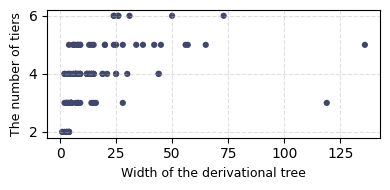

In [40]:
import matplotlib.pyplot as plt

def tree_width_and_tiers(root):
    return calculate_width(root), calculate_depth(root)

widths = []
tiers_list = []
for tree in WF_Trees:
    root = tree.vert
    w, t = tree_width_and_tiers(root)
    if w >= 100: print(tree.vert.text, ' ', w)
    widths.append(w)
    tiers_list.append(t)

print(sum(widths) / len(widths))

# Построение scatter plot
plt.figure(figsize=(4, 2))
plt.scatter(widths, tiers_list, color='#40466e', alpha=1, edgecolor='none', linewidth=1, s = 20)

plt.xlabel("Width of the derivational tree", fontsize=9)
plt.ylabel("The number of tiers", fontsize=9)
plt.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

###работа с файлами со статистикой по ошибкам

In [ ]:
import chardet
import re

def detect_encoding(filename):
    with open(filename, 'rb') as file:
        raw_data = file.read(10000)  # Читаем первые 10KB для определения кодировки
    return chardet.detect(raw_data)['encoding']

def process_file(filename):
    try:
        encoding = detect_encoding(filename)

        total_lines = 0
        sum_accuracy1 = 0.0
        sum_accuracy2 = 0.0
        no_mistakes_trees = 0

        with open(filename, 'r', encoding=encoding) as file:
            for line in file:
                line = line.strip()
                if not line:
                    continue

                try:
                    # Используем регулярное выражение для более надежного парсинга
                    match = re.match(r'^(\d+)\.\s+(\d+)\s+-\s+(\d+)\s+/\s+(\d+)\s+([а-яА-ЯёЁ-]+)', line)
                    if not match:
                        print(f"Не удалось разобрать строку: {line}")
                        continue

                    line_number = match.group(1)
                    N = int(match.group(2))
                    o = int(match.group(3))
                    O = int(match.group(4))
                    S = match.group(5)

                    accuracy1 = (N - 1 - o) / (N - 1)
                    accuracy2 = (N - 1 - O) / (N - 1)
                    if o == 0: no_mistakes_trees += 1

                    print(f"{line_number}. {S}     {accuracy1:.4f} / {accuracy2:.4f}")

                    total_lines += 1
                    sum_accuracy1 += accuracy1
                    sum_accuracy2 += accuracy2

                except Exception as e:
                    print(f"Ошибка при обработке строки '{line}': {e}")
                    continue

        avg_accuracy1 = sum_accuracy1 / total_lines
        avg_accuracy2 = sum_accuracy2 / total_lines
        print(f"\nСредняя точность 1: {avg_accuracy1:.4f}")
        print(f"Средняя точность 2: {avg_accuracy2:.4f}")
        print(f"Деревьев без ошибок: {no_mistakes_trees}")

    except Exception as e:
        print(e)

process_file('mistakes.txt')

[Errno 2] No such file or directory: 'mistakes.txt'


In [ ]:
import chardet
import re

def detect_encoding(filename):
    with open(filename, 'rb') as file:
        raw_data = file.read(10000)
    return chardet.detect(raw_data)['encoding']

def format_number(num):
    """Форматирует число с 4 знаками после запятой"""
    return f"{num:.4f}"

def process_file(filename):
    try:
        encoding = detect_encoding(filename)
        print(f"Определена кодировка файла: {encoding}\n")

        total_lines = 0
        sum_accuracy1 = 0.0
        sum_accuracy2 = 0.0
        no_mistakes_trees = 0
        sum_N = 0
        sum_o = 0
        sum_O = 0

        with open(filename, 'r', encoding=encoding) as file:
            for line in file:
                line = line.strip()
                if not line:
                    continue

                try:
                    # Разбираем строку с помощью регулярного выражения
                    match = re.match(r'^(\d+)\.\s+(\d+)\s+-\s+(\d+)\s+/\s+(\d+)\s+([а-яА-ЯёЁ-]+)\s*(.*)$', line)
                    if not match:
                        print(f"Не удалось разобрать строку: {line}")
                        continue

                    line_number = match.group(1)
                    N = int(match.group(2))
                    o = int(match.group(3))
                    O = int(match.group(4))
                    S = match.group(5)
                    other_chars = match.group(6)
                    if o == 0: no_mistakes_trees += 1
                    sum_N += (N-1)
                    sum_o += o
                    sum_O += O

                    # Вычисляем точности
                    if N == 1:
                        accuracy1 = accuracy2 = 0.0
                    else:
                        accuracy1 = (N - 1 - o) / (N - 1)
                        accuracy2 = (N - 1 - O) / (N - 1)

                    # Форматируем вывод с выравниванием
                    line_num_part = f"{line_number}.".ljust(5)
                    s_part = S.ljust(10)
                    n_part = f"({N} слов)".ljust(10)
                    errors_part = f"ошибки / ошибки с учетом семантики:".ljust(35)
                    o_part = f"{o} / {O}".ljust(10)
                    accuracy_part = f"точность / точность с учетом семантики:".ljust(40)
                    accuracy_values = f"{format_number(accuracy1)} / {format_number(accuracy2)}"
                    other_part = f"   {other_chars}" if other_chars else ""

                    # Собираем строку вывода
                    output_line = (
                        f"{line_num_part} {s_part} {n_part} "
                        f"{errors_part} {o_part} "
                        f"{accuracy_part} {accuracy_values} "
                        f"{other_part}"
                    )

                    print(output_line.rstrip())

                    # Суммируем для средних
                    total_lines += 1
                    sum_accuracy1 += accuracy1
                    sum_accuracy2 += accuracy2

                except Exception as e:
                    print(f"Ошибка при обработке строки: {line}\n{str(e)}")
                    continue

        # Выводим средние значения
        if total_lines > 0:
            avg_accuracy1 = sum_accuracy1 / total_lines
            avg_accuracy2 = sum_accuracy2 / total_lines

            print("\n" + "="*100)
            print("ИТОГО:".ljust(30))
            print(f"Средняя точность: {format_number(avg_accuracy1)}".ljust(40))
            print(f"Средняя точность с учетом семантики: {format_number(avg_accuracy2)}")
            print(f"Деревьев без ошибок: {no_mistakes_trees}")
            print(f"Всего ошибок / всего связей: {sum_o} / {sum_N}, общая точность {(sum_N - sum_o)/sum_N}")
            print(f"Всего ошибок c учетом семантики / всего связей: {sum_O} / {sum_N}, общая точность с учетом семантики {(sum_N - sum_O)/sum_N}")

    except Exception as e:
        print(f"Ошибка при работе с файлом: {e}")

# Укажите имя вашего файла
process_file('mistakes.txt')

Ошибка при работе с файлом: [Errno 2] No such file or directory: 'mistakes.txt'


In [ ]:
nest_file = "10_25_groups.txt" #json или txt файл с группами слов одного корня
vert_file = "10_25_verts.txt" #txt-файл с вершинами деревьев (можно оставить пустым)

Nests = Nests_from_file(nest_file)
Verts = Verts_from_file(vert_file)
print(len(Nests))

for Nest in Nests:
  t1 = sorted(Nest,  key=lambda word: (word.morph_len, word.len, word.pos_priority))[0]
  t2 = sorted(Nest,  key=lambda word: (word.morph_len, word.pos_priority, word.len))[0]
  wf_tree = WF_Tree(Nest,Verts)
  if not ((t1 == t2) and (t1 == wf_tree.vert)): print(wf_tree.vert, '    ', t1, '     ', t2)

nest_file = "groupped_words_new.txt" #json или txt файл с группами слов одного корня
vert_file = "custom_vertices_new.txt" #txt-файл с вершинами деревьев (можно оставить пустым)

Nests = Nests_from_file(nest_file)
Verts = Verts_from_file(vert_file)
print(len(Nests))

for Nest in Nests:
  t1 = sorted(Nest,  key=lambda word: (word.morph_len, word.len, word.pos_priority))[0]
  t2 = sorted(Nest,  key=lambda word: (word.morph_len, word.pos_priority, word.len))[0]
  wf_tree = WF_Tree(Nest,Verts)
  if not ((t1 == t2) and (t1 == wf_tree.vert)): print(wf_tree.vert, '    ', t1, '     ', t2)

nest_file = "groupped_words_test.txt" #json или txt файл с группами слов одного корня
vert_file = "custom_vertices_test.txt" #txt-файл с вершинами деревьев (можно оставить пустым)

Nests = Nests_from_file(nest_file)
Verts = Verts_from_file(vert_file)
print(len(Nests))

for Nest in Nests:
  t1 = sorted(Nest,  key=lambda word: (word.morph_len, word.len, word.pos_priority))[0]
  t2 = sorted(Nest,  key=lambda word: (word.morph_len, word.pos_priority, word.len))[0]
  wf_tree = WF_Tree(Nest,Verts)
  if not ((t1 == t2) and (t1 == wf_tree.vert)): print(wf_tree.vert, '    ', t1, '     ', t2)



4
дел-а-ть      дел-о       дел-а-ть
нос-и-ть      нош-а       нос-и-ть
36
веc-ти      вод-и-ть       вод-и-ть
вез-ти      воз       вез-ти
жи-в-ой      жи-в-и-ть       жи-в-и-ть
жид-к-ий      жиж-а       жиж-а
зверь      зверь       звер-е-ть
корот-к-ий      короч-е       корот-а-ть
лад-и-ть      лад       лад-и-ть
лаз-а-ть      лаз       лаз-а-ть
лож-и-ть      лож-е       лож-и-ть
нов-ый      нов-е-ть       нов-е-ть
при-вад-и-ть      при-вад-а       при-вад-и-ть
ясн-ый      ясн-е-ть       ясн-е-ть
70
брызг-а-ть      брызг-и       брызг-а-ть
бугор      бугор       бугр-и-ть
гад-и-ть      гад       гад-и-ть
грусть      грусть       груст-и-ть
дорог-ой      дорож-а-ть       дорож-а-ть
дрож-а-ть      дрожь       дрож-а-ть
дум-а-ть      дум-а       дум-а-ть
игр-а-ть      игр-а       игр-а-ть
конец      конец       конч-а-ть
лет-а-ть      лет-е-ть       лет-е-ть
мок-ну-ть      моч-а       моч-и-ть
раз-и-ть      раж       раз-и-ть
рас-ти      рост       рас-ти
род-и-ть      род-ы       род-

###сравнение размеров деревьев с многокоренными и без

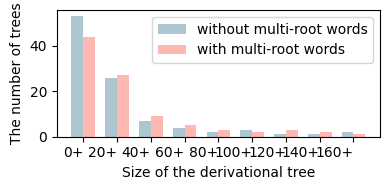

In [ ]:
def plot_size_distribution_grouped(WF_Trees):

    def size_without_mrw(node):
      if not len(node.children):
        if len(node.root) > 1: return 0
        return 1
      if len(node.root) > 1: return sum([size_without_mrw(x) for x in node.children])
      return sum([size_without_mrw(x) for x in node.children]) + 1


    # Извлекаем списки размеров, обрезая значения > 180
    size1 = [size_without_mrw(item.vert) for item in WF_Trees if size_without_mrw(item.vert) <= 180]
    size2 = [len(item.all_words) for item in WF_Trees if len(item.all_words) <= 180]

    max_val = 180

    # Генерируем интервалы с шагом 20 от 1 до 180
    intervals = []
    low = 1
    while low <= max_val:
        high = low + 19
        if high > max_val:
            high = max_val
        intervals.append((low, high))
        low += 20

    # Подсчитываем количество попаданий в каждый интервал
    counts1 = []
    counts2 = []
    for low, high in intervals:
        c1 = sum(1 for s in size1 if low <= s <= high)
        c2 = sum(1 for s in size2 if low <= s <= high)
        counts1.append(c1)
        counts2.append(c2)

    # Подписи для оси X
    labels = [f"{low - 1}+" for low, high in intervals]

    # Настройка для grouped bar
    x = np.arange(len(labels))
    width = 0.35

    fig, ax = plt.subplots(figsize=(4, 2))
    bars1 = ax.bar(x - width/2, counts1, width, label='without multi-root words', color='#AEC6CF')
    bars2 = ax.bar(x + width/2, counts2, width, label='with multi-root words', color='#FFB7B2')



    ax.set_xlabel('Size of the derivational tree')
    ax.set_ylabel('The number of trees')
    # Заголовок убран
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=0, ha='right')
    ax.legend()

    plt.tight_layout()
    plt.show()


plot_size_distribution_grouped(WF_Trees)

###Проценты POS

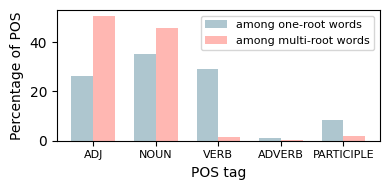

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def analyze_pos_distribution(trees):
    """
    trees: список объектов WF_Tree с полем vert (Word)
    Word имеет поля: pos (часть речи), children (список Word), root (список корней)
    Части речи из списка: VERB, NOUN, ADJ, ADVERB, PARTICIPLE
    """
    target_pos = ['ADJ', 'NOUN', 'VERB', 'ADVERB', 'PARTICIPLE']
    # Собираем все слова из деревьев (рекурсивно)
    all_words = []
    words_multiroot = []  # слова с len(root) > 1

    def collect(word):
        all_words.append(word)
        if len(word.root) > 1:
            words_multiroot.append(word)
        for child in word.children:
            collect(child)

    for tree in trees:
        collect(tree.vert)

    total_all = len(all_words)
    total_multi = len(words_multiroot)

    # Считаем количество слов каждой части речи среди всех слов
    counts_all = {pos: 0 for pos in target_pos}
    for w in all_words:
        if w.pos in counts_all:
            counts_all[w.pos] += 1
    # Проценты
    percent_all = {pos: (counts_all[pos] / total_all * 100) if total_all > 0 else 0
                   for pos in target_pos}

    # Считаем для слов с >1 корня
    counts_multi = {pos: 0 for pos in target_pos}
    for w in words_multiroot:
        if w.pos in counts_multi:
            counts_multi[w.pos] += 1
    percent_multi = {pos: (counts_multi[pos] / total_multi * 100) if total_multi > 0 else 0
                     for pos in target_pos}

    # Подписи для оси X
    labels = ['ADJ', 'NOUN', 'VERB', 'ADVERB', 'PARTICIPLE']

    # Настройка для grouped bar
    x = np.arange(len(labels))
    width = 0.35

    fig, ax = plt.subplots(figsize=(4, 2))
    bars1 = ax.bar(x - width/2, percent_all.values(), width, label='among one-root words', color='#AEC6CF')
    bars2 = ax.bar(x + width/2, percent_multi.values() , width, label='among multi-root words', color='#FFB7B2')

    ax.set_xlabel('POS tag')
    ax.set_ylabel('Percentage of POS')
    ax.set_xticks(x)
    # Изменения: центрируем подписи, уменьшаем их размер
    ax.set_xticklabels(labels, rotation=0, fontsize=8)   # ha='center' по умолчанию
    # Уменьшаем размер легенды в 1.5 раза (было ~9, стало 6)
    ax.legend(prop={'size': 8})

    plt.tight_layout()
    plt.show()

analyze_pos_distribution(WF_Trees)

#Многокоренные слова

###достаем готовые деревья для одного корня из файла

In [14]:
def parse_trees_from_file(filepath: str):
    with open(filepath, 'r', encoding='utf-8') as f:
        lines = f.read().splitlines()

    blocks = []
    current_block = []
    for line in lines:
        if '------' in line.strip():
            if current_block:
                blocks.append(current_block)
                current_block = []
        else:
            # Пропускаем абсолютно пустые строки (хотя в файле их нет)
            if not ('[' in line):
                current_block.append(line)
    if current_block:
        blocks.append(current_block)

    WF_Tree_s = []

    for block in blocks:
      WF_Tree_s.append(WF_Tree(filelist=block))

    return(WF_Tree_s)

In [15]:
filepath = 'derivational trees with morphem classification.txt'

WF_Tree_s = parse_trees_from_file(filepath)

###вручную составленные списки для алломорфов корней и аффиксоидов

In [16]:
prepared_one_root_groups = [
    #['слово - вершина гнезда',[список корневых алломорфов],[список уникальных корневых алломорфов, допустимых в многокоренных словах]]
['ваза', ['ваз'], ['ваз'], 3] ,
['вести', ['вожд', 'важ', 'вод', 'вад', 'веc', 'вож'], ['вожд', 'веc', 'вож'], 159] ,
['везти', ['вож', 'вез', 'воз'], ['вез', 'воз'], 133] ,
['вода', ['вож', 'вод'], ['вод'], 53] ,
['ждать', ['жд', 'жид'], ['жд'], 27] ,
['жевать', ['жев'], ['жев'], 35] ,
#['же-чь', ['жиг', 'жж', 'же', 'жег'], ['жиг', 'жж', 'же', 'жег']] ,
['живой', ['живл', 'жив'], ['живл', 'жив'], 46] ,
['жид', ['жид'], [], 5] ,
#['жид-к-ий', ['жид', 'жиж'], ['жиж', "жид"]] ,
['жила', ['жил', 'жиль'], ['жиль', 'жил'], 14] ,
['жилить', ['жил'], [], 5] ,
['жито', ['жит'], [], 5] ,
#['жи-ть', ['жи', 'жит'], ['жит', "жи"]] ,
['зверь', ['звер', 'зверь'], ['звер', 'зверь'], 23] ,
['короткий', ['кратч', 'корач', 'короч', 'крат', 'к', 'кратц', 'корот', 'кращ', 'крот'], ['кратч', 'корач', 'короч', 'крат', 'к', 'кратц', 'корот', 'кращ'], 51] ,
['крот', ['крот'], ['крот'], 5] ,
['ладить', ['лаг', 'лад', 'лаж'], ['лад', 'лаж'], 0] ,
['лазать', ['лаз'], ['лаз'], 0] ,
['лгать', ['лож', 'лж', 'лг'], ['лж', 'лг'], 22] ,
['ложа', ['лож'], [], 0] ,
['ложить', ['лаг', 'лог', 'лож'], ['лог', 'лаг', "лож"], 0] ,
['лоза', ['лоз'], ['лоз'], 7] ,
['мотать', ['мот', 'мат'], ['мот'], 109] ,
['мыслить', ['мысль', 'мысл', 'мысел', 'мышл'], ['мысел', 'мышл', 'мысл'], 83] ,
['новый', ['нов'], ['нов'], 51] ,
['ночь', ['ночь', 'ноч'], ['ночь', 'ноч'], 15] ,
#['от-вад-и-ть', ['важ', 'вад'], []] ,
#['при-вад-и-ть', ['важ', 'вад'], []] ,
['узда', ['узд'], ['узд'], 12] ,
['утро', ['утр'], ['утр'], 15] ,
['форма', ['форм', 'формл'], ['форм', 'формл'], 94] ,
['щемить', ['щем'], ['щем'], 9] ,
['экзамен', ['экзамен'], ['экзамен'], 23] ,
['ясный', ['ясн'], ['ясн'], 58] ,
['борт', ['борт'], ['борт'], 14] ,
['борть', ['борт'], [], 7] ,
['брызгать', ['брызг', 'брызж'], ['брызг', 'брызж'], 44] ,
['бугор', ['бугр', 'бугор'], ['бугр', 'бугор'], 11] ,
['гага', ['гаг'], ['гаг'], 2] ,
['гадать', ['гад'], ['гад'], 58] ,
['гадить', ['гад', 'гаж'], ['гаж'], 29] ,
['год', ['год'], ["год"], 12] ,
['годить', ['год', 'гож', 'гад'], ['гож'], 19] ,
['грусть', ['груст'], ['груст'], 20] ,
['дорога', ['дорож', 'дорог'], ['дорож', "дорог"], 0] ,
['дорогой', ['дорож', 'драж', 'дорог', "драг"], ['драг', "драж"], 0] ,
['драже', ['драж', 'драже'], ['драже', 'драж'], 5] ,
['дрожать', ['дрож', 'драг', 'дрог'], ['дрож', 'дрог'], 29] ,
['думать', ['дум'], ['дум'], 111] ,
['жмурить', ['жмур'], ['жмур'], 18] ,
['играть', ['ыгр', 'игор', 'игр'], ['ыгр', 'игор', 'игр'], 104] ,
['кадить', ['кад', 'кажд'], [], 3] ,
['кант', ['кант'], ['кант'], 16] ,
#['кант', ['кант'], [], 4] , #единственный случай совпадающих вершин, потому что тут Кант - имя собственное
['код', ['код'], ['код'], 21] ,
['кожа', ['кож'], ['кож'], 19] ,
['коза', ['коз'], ['коз'], 20] ,
['конец', ['конч', 'канч', 'конец', 'конеч', 'конц'], ['конч', 'канч', 'конец', 'конеч', 'конц'], 54] ,
['крыло', ['крыл'], ['крыл'], 35] ,
['летать', ['лет'], ["лет"], 0] ,
['лето', ['лет'], [], 0] ,
['лить', ['ли'], ['ли'], 158] ,
['лик', ['лик'], ['лик'], 3] ,
['лицо', ['лиц', 'лич'], ['лиц', 'лич'], 64] ,
['луна', ['лун'], ['лун'], 18] ,
['мак', ['мак'], ['мак'], 9] ,
['макать', ['мак'], [], 19] ,
['маска', ['маск'], ['маск'], 20] ,
['масть', ['маст'], ['маст'], 3] ,
['матовый', ['мат'], [], 7] ,
['мать', ['мач', 'мат'], ['мач', 'мат'], 24] ,
['мокнуть', ['моч', 'мач', 'мок'], ['моч', 'мок'], 146] ,
['мост', ['мост'], [], 13] ,
['мостить', ['мост', 'мащ', 'мощ'], ['мащ'], 33] ,
['мот', ['мот'], [], 5] ,
['мощь', ['мощ'], ['мощ'], 10] ,
['перед', ['переж', 'перед','прежде'], ['переж', 'перед'], 24] ,
['пехота', ['пех'], ['пех'], 5] ,
['пеший', ['пеш', 'пёх'], ['пеш', 'пёх'], 9] ,
['писать', ['пис', 'пиш'], ['пис', 'пиш'], 164] ,
['пихать', ['пих'], ['пих'], 77] ,
['радий', ['рад'], ['рад'], 7] ,
['радио', ['рад', 'радио'], ['радио'], 5] ,
['радый', ['рад'], [], 23] ,
['разить', ['раз', 'раж'], ['раж'], 23] ,
['раса', ['рас'], [], 5] ,
['расти', ['раст', 'ращ', 'рощ', 'рас', 'рост', 'рос'], ['раст', 'ращ', 'рощ', 'рост', 'рос'], 180] ,
['рог', ['рож', 'рог'], ['рог'], 28] ,
['родить', ['рожд', 'рож', 'род'], ['рожд', 'род', 'рож'], 102] ,
['рожа', ['рож'], ['рож'], 3] ,
['роза', ['роз'], ['роз'], 12] ,
['роса', ['рос'], [], 10] ,
['рысь', ['рыс'], ['рыс'], 14] ,
['собака', ['собач', 'собак'], ['собач', 'собак'], 19] ,
['стирать', ['стир'], ['стир'], 58] ,
['тема', ['тем'], [], 5] ,
['темя', ['тем'], [], 4] ,
['тмин', ['тмин'], ['тмин'], 2] ,
['тьма', ['тм', 'тем', 'темн', 'тьм'], ['тм', 'темн', 'тьм', 'тем'], 63] ,
['цинк', ['цинк'], ['цинк'], 15] ,
['червь', ['черв'], ['черв'], 13] ,
['шерсть', ['шерст'], ['шерст'], 14] ,
['шикать', ['ши'], [], 7] ,
['шить', ['шив', 'шов', 'шв', 'ши'], ['шив', 'шов', 'шв'], 129] ,
# #['дел-а-ть', ['дел'], []],
# #['дел-и-ть', ['дел'], []],
['нос', ['нос'], [], 11],
['носить', ['нос', 'нес', 'наш', 'нош'], ['нес', 'наш', 'нош', "нос"], 261],
['шагать',["шаг", "шаж"],["шаг", "шаж"], 36],
['истребить',["истреб"],["истреб"], 17],
['мешок',["мешк","мешот","мешоч", "мешок"],["мешк","мешот","мешоч", "мешок"], 11],
['щадить',["щад","щаж"],["щад","щаж"], 15],
['обречь',["обрек","обреч","обречь"],["обрек","обреч","обречь"], 10],
['фабрика',["фабрик","фабрич", "фабриц"],["фабрик","фабрич", "фабриц"], 28],
['ерник',['ерник', 'ернич'],['ерник', 'ернич'], 4],
['сермяга',["сермяг","сермяж"],["сермяг","сермяж"], 5],
['америка',["америк", "америц"],["америк", "америц"], 18],
['хиреть',["хир"],["хир"], 5]
]


In [17]:
prefixoids = [
    #['префиксоид', 'вершина гнезда']
    ['аква', 'заимствование'],
    ['анти', 'заимствование'],
    ['архи', 'заимствование'],
    ['авиа', 'заимствование'],
    ['авто', 'заимствование'],
    ['ауто', 'заимствование'],
    ['аэро', 'заимствование'],
    ['био', 'заимствование'],
    ['близ', 'близ'],
    ['взаимо', 'иметь'],
    ['взаимно', 'иметь'],
    ['вице', 'заимствование'],
    ['вне', 'вне'],
    ['внутри', 'нутро'],
    ['высоко', 'высокий'],
    ['гипер', 'заимствование'],
    ['гранд', 'заимствование'],
    ['едино', 'один'],
    ['еже', "иже"],
    ['интер','заимствование'],
    ['интра','заимствование'],
    ['интро','заимствование'],
    ['инфра','заимствование'],
    ['квази','заимствование'],
    ['кон', 'заимствование'],
    ['контр','заимствование'],
    ['контра','заимствование'],
    ['макро', 'заимствование'],
    ['микро', 'заимствование'],
    ['мега', 'заимствование'],
    ['мета', 'заимствование'],
    ['много','многий'],
    ['мало', "малый"],
    ['моно', 'заимствование'],
    ['мото', 'заимствование'],
    ['мульти','заимствование'],
    ['нео', 'заимствование'],
    ['обер', 'заимствование'],
    ['обще', "общий"],
    ['около', "около"],
    ['пан', 'заимствование'],
    ['пара', 'заимствование'],
    ['поли', 'заимствование'],
    ['полу',"пол"],
    ['пол', "пол"],
    ['после', "после"],
    ['прежде',  "перед"],
    ['пост', 'заимствование'],
    ['псевдо','заимствование'],
    ['противо', "против"],
    ['равно', "равный"],
    ['само',  "сам"],
    ['сверх',"верх"],
    ['спец', "сокращение"],
    ['среди', "среда"],
    ['суб', 'заимствование'],
    ['супер', 'заимствование'],
    ['супра','заимствование'],
    ['транс', 'заимствование'],
    ['ультра', 'заимствование'],
    ['экс', 'заимствование'],
    ['экстра', 'заимствование'],
    ['электро', 'заимствование'],
    ['энерго', 'заимствование'],
    ['дву', "два"],
    ['двух', "два"],
    ['два',  "два"],
    ['две', "два"],
    ['двою', "два"],
    ['одно', "один"],
    ['три', "три"],
    ['трою', "три"],
    ['трех', "три"],
    ['четырех', "четыре"],
    ['пяти', "пять"],
    ['шести', "шесть"],
    ['полтора', "пол, второй"],
    ['полутора',"пол, второй"],
    ['арт', 'заимствование'],
    ['гео', 'заимствование'],
    ['дека','заимствование'],
    ['зоо', 'заимствование'],
    ['кило','заимствование'],
    ['кино', 'заимствование'],
    ['милли', 'заимствование'],
    ['мото', 'заимствование'],
    ['пресс', 'заимствование'],
    ['теле', 'заимствование'],
    ['фото', 'заимствование'],
    ['ложно','лгать'],
    ['лето','лета'],
    ['летне','лето'],
    ['провод','вести'],
    ['производ','вести']
]

suffixoids = [
    #['суффиксоид', 'слово, от которого образован суффиксоид', 'вершина гнезда']
    ['провод', "вести"],
    ['вед', "ведать"],
    ['видный', "видеть"],
    ['вод', "вести"],
    ['воз', "везти"],
    ['градусный', "градус"],
    ['граф', 'заимствование'],
    ['графия','заимствование'],
    ['дел', "делать"],
    ['дневный', "день"],
    ['люб', "любить"],
    ['мейстер', 'заимствование'],
    ['мер', "мерить"],
    ['метр', 'заимствование'],
    ['носец', "носить"],
    ['носый','нос'],
    ['носик','нос'],
    ['образный', "образ"],
    ['подобный', 'подобный'],
    ['содержащий', "держать"],
    ['сотенный', "сто"],
    ['терапия', 'заимствование'],
    ['тематический', 'тема'],
    ['творный', "творить"],
    ['тысячный', "тысяча"],
    ['устойчивый', "стать"],
    ['ход', "ход"],
    ['этажный', "этаж"],
    ['летие','лета'],
    ['леток','лета'],
    ['летний','лета'],
    ['летка','лета'],
    ['летник','лета'],
    ['радост','радый'],
    ['радн','радый'],
    ['радство','радый'],
    ['радист','радио']
]

In [18]:
print(len(suffixoids))

37


In [19]:
def index_prepared(tree):
  L = [x[0] for x in prepared_one_root_groups]
  if tree.vert.text in L: return L.index(tree.vert.text)
  else: return(None)

#убираем из деревьев те, с которыми пока не готовы работать
WF_Trees = []
for tree in WF_Tree_s:
  if index_prepared(tree): WF_Trees.append(tree)
  else: print(tree.vert.text)

###подгружаем многокоренные слова из датасета

In [20]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [21]:

with open('/content/drive/MyDrive/dataset/от_Анны/RuMorphs-Lemmas-filtered_2root.txt', 'r', encoding='utf-8') as file:
    RML = file.readlines()

data = [Word(x.replace("/t", " ").split()[1]) for x in RML if (not ('самолето-вылет' in x)) and (not ('рад-радешенек' in x)) and (not ('рад-радехонек' in x)) and (not ('приливо-отливной' in x)) and (not ('стираный-перестираный' in x)) and (not ('темным-темно' in x)) and (not ('тьма-тьмущая' in x)) and (not ('приливо-отливный' in x))]

###функции определения словообразовательной связи

In [22]:
def similar_0(parent, child):
  part_p = parent.pref+parent.root+parent.suff+parent.postfix
  part_c = child.pref+child.root+child.suff+child.postfix
  if (len(part_p) != len(part_c)): return False
  for i in range(len(part_p)):
    if not (part_p[i] == part_c[i]): return False
  return True

In [23]:
def similar_1(parent, child):
  if ((parent.root+parent.suff+parent.postfix == child.root+child.suff+child.postfix) and
      (len(child.pref) > 0) and (parent.pref == child.pref[1:])): return True
  suff_diff_1 = [x for x in child.suff if x not in parent.suff]
  suff_diff_2 = [x for x in parent.suff if x not in child.suff]
  if ((parent.pref+parent.root+parent.postfix == child.pref+child.root+child.postfix) and
      (len(suff_diff_2) == 0) and (len(suff_diff_1) == 1)): return True
  if ((parent.pref+parent.root+parent.suff == child.pref+child.root+child.suff) and
      (len(child.postfix) > 0) and (parent.postfix == child.postfix[:-1])): return True
  return False

In [24]:
def similar_2(parent, child):
  suff_diff_1 = [x for x in child.suff if x not in parent.suff]
  suff_diff_2 = [x for x in parent.suff if x not in child.suff]
  if ((parent.pref+parent.root+parent.postfix == child.pref+child.root+child.postfix) and
      (len(suff_diff_2) == 0) and (len(suff_diff_1) == 2)): return True
  if ((parent.pref == child.pref) and (parent.root == child.root) and
      (len(suff_diff_2) == 0) and (len(suff_diff_1) == 1) and
      (len(child.postfix) > 0) and (parent.postfix == child.postfix[:-1])): return True
  if ((parent.postfix == child.postfix) and (parent.root == child.root) and
      (len(suff_diff_2) == 0) and (len(suff_diff_1) == 1) and
      (len(child.pref) > 0) and (parent.pref == child.pref[1:])): return True
  if ((parent.suff == child.suff) and (parent.root == child.root) and
      (len(child.postfix) > 0) and (parent.postfix == child.postfix[:-1]) and
      (len(child.pref) > 0) and (parent.pref == child.pref[1:])): return True
  return False

###шаг 0: делим слова по семействам

In [25]:
for i in range(len(prepared_one_root_groups)):
  prepared_one_root_groups[i].append(list())
  prepared_one_root_groups[i].append(list())

def index(word):
  for i in range(len(prepared_one_root_groups)):
    if prepared_one_root_groups[i][0] == word: return i
  return None

In [26]:
def num_root(pref, roots):
  for i in range(len(roots)):
    if roots[i] in pref: return i
  return 6

for word in data:
  roots = word.root
  for suffixoid in suffixoids:
    if (suffixoid[0] in word.text) and (roots[-1] in suffixoid[0]):
      if index(suffixoid[1]): prepared_one_root_groups[index(suffixoid[1])][4].append(word)
      roots.pop(-1)
      break
  for prefixoid in prefixoids:
    if (prefixoid[0] in word.text) and (num_root(prefixoid[0], roots) < len(roots)-1):
       if index(prefixoid[1]): prepared_one_root_groups[index(prefixoid[1])][4].append(word)
       roots.pop(num_root(prefixoid[0], roots))
  for root in roots:
     for i in range(len(prepared_one_root_groups)):
        if root in prepared_one_root_groups[i][2]:
          if not (word in prepared_one_root_groups[i][4]): prepared_one_root_groups[i][4].append(word)
          break

In [27]:
for i in range(len(prepared_one_root_groups)):
  prepared_one_root_groups[i][4] = sorted(prepared_one_root_groups[i][4],  key=lambda word: (word.morph_len, word.pos_priority, word.text))

###шаг 1: присоединение слов с совпадающей основой

In [28]:
#основа с нужным корнем по слову и вершине дерева

def split_morphemes(s: str):
    elements = s.split('/')
    result = []
    current = []
    has_root = False

    for elem in elements:
        if ':' not in elem:
            continue
        part, tag = elem.split(':', 1)
        tag = tag.strip()
        if tag in ('LINK', 'END', 'HYPH'):
            continue

        if tag == 'ROOT':
            if has_root:
                result.append('/'.join(current))
                current = []
                has_root = False
            current.append(part+':'+tag)
            has_root = True

        elif tag == 'PREF':
            if has_root:
                result.append('/'.join(current))
                current = []
                has_root = False
            current.append(part+':'+tag)

        elif tag in ('SUFF', 'POSTFIX'):
            current.append(part+':'+tag)
    if current:
        result.append('/'.join(current))
    return result

def osnova(word, vert):
  osnovs = [Word(x) for x in split_morphemes(word.string)]
  for o in osnovs:
    i = index(vert.text)
    for allomorph in prepared_one_root_groups[i][1]:
      if allomorph == o.root[0]:
        if Word('лж:ROOT') == o: return Word('лож:ROOT/н:SUFF')
        return o
  print(word)

In [29]:
def step_1(tree):
  i = index(tree.vert.text)
  if not i: print(tree.vert.text)
  parents_with_mrc = []
  parents = []
  parents.append(tree.vert)

  while len(parents):
    parent = parents.pop()
    for child in parent.children: parents.append(child)
    candidates = prepared_one_root_groups[i][4][:]
    while len(candidates):
      candidate = candidates.pop()
      o = osnova(candidate, tree.vert)
      if similar_0(parent, o):
        candidate.stepflag = 'step_1'
        parent.children.append(candidate)
        prepared_one_root_groups[i][4].remove(candidate)
        prepared_one_root_groups[i][5].append(candidate)
        tree.all_words.append(candidate)
        if not parent in parents_with_mrc: parents_with_mrc.append(parent)

  for parent in parents_with_mrc:
    mr_words_1 = sorted([x for x in parent.children if len(x.root) > 1],  key=lambda word: (word.morph_len, word.len, word.pos_priority, word.text))
    mr_words_2 = [x for x in mr_words_1]
    for i_1 in range(len(mr_words_1)-1):
      for i_2 in range(i_1+1, len(mr_words_2)):
        sm1 = split_morphemes(mr_words_1[i_1].string)
        sm2 = split_morphemes(mr_words_2[i_2].string)
        if ((similar_1(mr_words_1[i_1], mr_words_2[i_2])) or
            (sm1 == sm2[:-1]) or (sm1 == sm2[1:])):
            if not (mr_words_2[i_2] in parent.children): print(mr_words_1[i_1], ' ', mr_words_2[i_2])
            parent.children.remove(mr_words_2[i_2])
            mr_words_1[i_1].children.append(mr_words_2[i_2])
            mr_words_2[i_2] = Word('абракадабра:ROOT')

###шаг 2: присоединение суффиксальных слов к сложным

In [30]:
def step_2(tree):
  i = index(tree.vert.text)
  if not i: print(tree.vert.text)
  parents = prepared_one_root_groups[i][5]
  while len(parents):
    parent = parents.pop()
    candidates = prepared_one_root_groups[i][4][:]
    for candidate in candidates:
      if similar_1(parent, candidate):
        candidate.stepflag = 'step_2'
        parent.children.append(candidate)
        prepared_one_root_groups[i][4].remove(candidate)
        prepared_one_root_groups[i][5].append(candidate)
        tree.all_words.append(candidate)
        parents.append(candidate)

###шаг 3: присоединение сложно-аффиксальных слов с 1 аффиксом

In [31]:
def step_3(tree):
  i = index(tree.vert.text)
  if not i: print(tree.vert.text)
  parents = []
  parents.append(tree.vert)
  while len(parents):
    parent = parents.pop()
    for child in parent.children: parents.append(child)
    candidates = prepared_one_root_groups[i][4][:]
    for candidate in candidates:
      o = osnova(candidate, tree.vert)
      if similar_1(parent, o):
        candidate.stepflag = 'step_3'
        parent.children.append(candidate)
        prepared_one_root_groups[i][4].remove(candidate)
        prepared_one_root_groups[i][5].append(candidate)
        tree.all_words.append(candidate)
        return True
  return False

###шаг 4: присоединение суффиксальных слов к сложным с 2 аффиксами

In [32]:
def step_4(tree):
  i = index(tree.vert.text)
  if not i: print(tree.vert.text)
  parents = prepared_one_root_groups[i][5]
  while len(parents):
    parent = parents.pop()
    candidates = prepared_one_root_groups[i][4][:]
    for candidate in candidates:
      if similar_2(parent, candidate):
        candidate.stepflag = 'step_4'
        parent.children.append(candidate)
        prepared_one_root_groups[i][4].remove(candidate)
        prepared_one_root_groups[i][5].append(candidate)
        tree.all_words.append(candidate)
        parents.append(candidate)
        return True
  return False

###шаг 5: присоединение сложно-аффиксальных слов с 2 аффиксами

In [33]:
def step_5(tree):
  i = index(tree.vert.text)
  if not i: print(tree.vert.text)
  parents = []
  parents.append(tree.vert)
  while len(parents):
    parent = parents.pop()
    for child in parent.children: parents.append(child)
    candidates = prepared_one_root_groups[i][4][:]
    for candidate in candidates:
      o = osnova(candidate, tree.vert)
      if similar_2(parent, o):
        candidate.stepflag = 'step_5'
        parent.children.append(candidate)
        prepared_one_root_groups[i][4].remove(candidate)
        prepared_one_root_groups[i][5].append(candidate)
        tree.all_words.append(candidate)
        return True
  return False

###шаг 6: присоединение всего остального

In [34]:
def check_sublist(sublist, larger_list):
    sublist_length = len(sublist)
    larger_list_length = len(larger_list)
    for i in range(larger_list_length - sublist_length + 1):
        if larger_list[i:i + sublist_length] == sublist:
            return True
    return False


def step_6(tree):
  i = index(tree.vert.text)
  if not i: print(tree.vert.text)
  differ = 20
  chosen = None
  candidate = prepared_one_root_groups[i][4].pop()
  #print(candidate, '  on step_6')
  c = [(x, 'PREF') for x in candidate.pref]+ [(x, 'ROOT') for x in candidate.root] + [(x, 'SUFF') for x in candidate.suff]+ [(x, 'POSTFIX') for x in candidate.postfix]
  for parent in tree.all_words:
    p = [(x, 'PREF') for x in parent.pref]+ [(x, 'ROOT') for x in parent.root] + [(x, 'SUFF') for x in parent.suff]+ [(x, 'POSTFIX') for x in parent.postfix]
    if check_sublist(p, c) and (len(c) - len(p) < differ):
      differ = len(c) - len(p)
      chosen = parent
  if not chosen: chosen = tree.vert
  candidate.stepflag = 'step_6'
  chosen.children.append(candidate)
  prepared_one_root_groups[i][5].append(candidate)
  tree.all_words.append(candidate)


###алгоритм присоединения многокоренных слов

In [35]:
for tree in WF_Trees:
  i = index(tree.vert.text)
  #print(tree.vert.text)
  if len(prepared_one_root_groups[i][4]) == 0: continue

  step_1(tree)
  step_2(tree)

  while step_3(tree):
    #print('step_3')
    step_2(tree)

  while step_4(tree):
    #print('step_4')
    step_2(tree)
    while step_3(tree):
      step_2(tree)

  while step_5(tree):
    #print('step_5')
    step_2(tree)
    while step_3(tree):
      step_2(tree)
    while step_4(tree):
      step_2(tree)
      while step_3(tree):
        step_2(tree)

  while len(prepared_one_root_groups[i][4]) > 0:
      step_6(tree)
      #print('step_6')
      step_2(tree)
      while step_3(tree):
        step_2(tree)
      while step_4(tree):
        step_2(tree)
        while step_3(tree):
          step_2(tree)
      while step_5(tree):
        step_2(tree)
        while step_3(tree):
          step_2(tree)
        while step_4(tree):
          step_2(tree)
          while step_3(tree):
            step_2(tree)

###вывод результатов работы алгоритма

In [ ]:
def find_multiple_root_pairs(root_word):
    result = []
    def dfs(node, parent):
        if parent is not None and len(node.root) > 1:
            result.append((parent.morph_spl, node.morph_spl))
        for child in node.children:
            dfs(child, node)
    dfs(root_word, None)
    return result

In [ ]:
# import pandas as pd

# def save_pairs_to_excel(pairs, filename="word_pairs.xlsx"):
#     df = pd.DataFrame(pairs, columns=["Производящее_слово", "Многокоренное_слово","шаг алгоритма"])
#     df.to_excel(filename, index=False)
#     print(f"Файл '{filename}' успешно сохранён с {len(pairs)} парами.")

In [ ]:
# pairs = []
# for tree in WF_Trees:
#   x = find_multiple_root_pairs(tree.vert)
#   if x: pairs = pairs + sorted(x, key=lambda x: x[1][::-1])+[('   ','   ','   ')]+[('------------','------------','-----------')]+[('   ','   ','   ')]

# save_pairs_to_excel(pairs, filename="word_pairs.xlsx")

In [ ]:
pairs = []
for tree in WF_Trees:
  x = find_multiple_root_pairs(tree.vert)
  if x: pairs = pairs + [(tree.vert.text,'('+str(len(x))+')')] + sorted(x, key=lambda x: x[0])+[('------------','------------')]

with open('пары.txt', 'w', encoding='utf-8') as f:
    for a, b in pairs:
        line = f"{str(a):<25}{str(b):<40}"
        f.write(line + '\n')

###таблицы частотности пар производящее-производное

In [ ]:
def analyze_links(trees):
    """
    trees: список объектов WF_Tree, у каждого есть поле vert (Word)
    Word имеет поля: pos (часть речи), children (список Word), root (список корней)
    """
    parts = ['VERB', 'NOUN', 'ADJ', 'ADVERB', 'PARTICIPLE']
    links = []  # (parent_pos, child_pos, child_root_len)

    # Рекурсивный сбор всех связей родитель -> ребёнок
    def dfs(word):
        for child in word.children:
            links.append((word.pos, child.pos, len(child.root)))
            dfs(child)

    for tree in trees:
        dfs(tree.vert)

    total = len(links)
    print(f"Всего связей: {total}\n")

    # Вспомогательная функция для печати таблицы процентов
    def print_table(title, link_pairs, total_count):
        print(title)
        print("=" * 80)
        # Заголовок
        header = "Parent\\Child".ljust(12)
        for p in parts:
            header += p.center(10)
        print(header)
        print("-" * (12 + 10 * len(parts)))
        # Строки для каждого родителя
        for parent in parts:
            row = parent.ljust(12)
            for child in parts:
                cnt = sum(1 for p, c in link_pairs if p == parent and c == child)
                percent = (cnt / total_count * 100) if total_count > 0 else 0.0
                row += f"{percent:9.2f}% "
            print(row)
        print()

    # 1. Проценты для всех связей
    all_pairs = [(p, c) for p, c, _ in links]
    print_table("Проценты для всех связей:", all_pairs, total)

    # 2. Проценты только для связей, где у производного >1 корня
    multi_links = [(p, c) for p, c, root_len in links if root_len > 1]
    total_multi = len(multi_links)
    print(f"Связей, где производное имеет >1 корня: {total_multi}\n")
    if total_multi > 0:
        print_table("Проценты для связей с производным, имеющим >1 корня:", multi_links, total_multi)
    else:
        print("Нет связей, где производное имеет более одного корня.")

In [ ]:
analyze_links(WF_Trees)

Всего связей: 4183

Проценты для всех связей:
Parent\Child   VERB      NOUN      ADJ      ADVERB  PARTICIPLE
--------------------------------------------------------------
VERB            25.82%     11.64%      3.06%      0.12%      7.75% 
NOUN             1.82%     17.95%     11.98%      0.31%      0.33% 
ADJ              1.17%      4.28%      9.75%      0.57%      0.14% 
ADVERB           0.00%      0.02%      0.02%      0.02%      0.02% 
PARTICIPLE       0.00%      0.26%      1.29%      0.00%      0.41% 

Связей, где производное имеет >1 корня: 1003

Проценты для связей с производным, имеющим >1 корня:
Parent\Child   VERB      NOUN      ADJ      ADVERB  PARTICIPLE
--------------------------------------------------------------
VERB             0.60%      6.28%      2.89%      0.10%      0.50% 
NOUN             0.60%     33.30%     22.53%      0.00%      0.10% 
ADJ              0.20%      5.68%     21.73%      0.30%      0.30% 
ADVERB           0.00%      0.10%      0.10%      0.00%   